# TP 17 — CNN Fashion MNIST : solution commentée

Solution complète du [TP 17](./17_cnn-fashion_enonce.ipynb).


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

torch.manual_seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_ROOT = "data"
FASHION_CLASSES = [
    "T-shirt/top",
    "Pantalon",
    "Pull",
    "Robe",
    "Manteau",
    "Sandale",
    "Chemise",
    "Sneaker",
    "Sac",
    "Bottine",
]

## Exercice 1 — Données


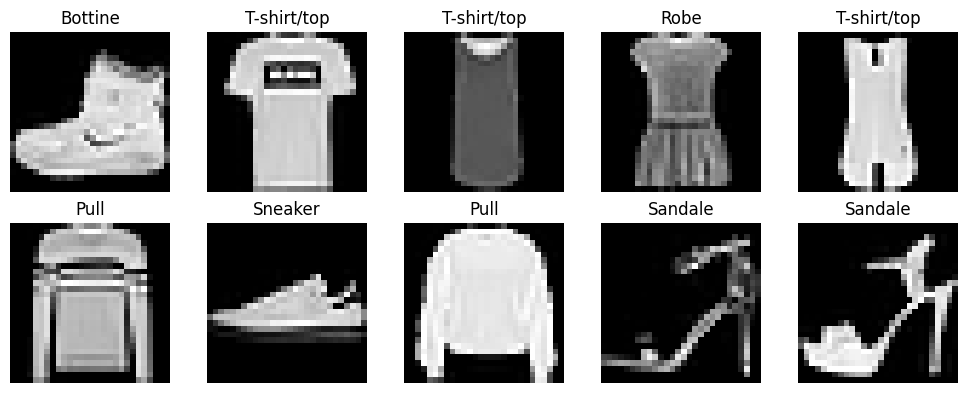

In [3]:
tf = transforms.ToTensor()
train_full = datasets.FashionMNIST(DATA_ROOT, train=True, download=True, transform=tf)
test_full = datasets.FashionMNIST(DATA_ROOT, train=False, download=True, transform=tf)
train_ds = Subset(train_full, range(5000))
test_ds = Subset(test_full, range(1000))

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)


fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    x, y = train_ds[i]
    ax.imshow(x.squeeze(), cmap="gray")
    ax.set_title(FASHION_CLASSES[y])
    ax.axis("off")
plt.tight_layout()

## Exercice 2 — CNN à 3 blocs


In [4]:
class FashionNet(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 28 -> 14
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 14 -> 7
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 7 -> 3 (floor)
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 128),  # 128 canaux * 3 * 3
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        return self.head(self.block3(self.block2(self.block1(x))))


model = FashionNet().to(DEVICE)
print("output shape :", model(torch.zeros(1, 1, 28, 28).to(DEVICE)).shape)
print("params :", sum(p.numel() for p in model.parameters()))

output shape : torch.Size([1, 10])
params : 287722


In [5]:
def train_one_epoch(model, loader, opt, loss_fn):
    model.train()
    total, correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        pred = model(x)
        loss = loss_fn(pred, y)
        loss.backward()
        opt.step()
        total += loss.item() * x.size(0)
        correct += (pred.argmax(1) == y).sum().item()
        n += x.size(0)
    return total / n, correct / n


def evaluate(model, loader, loss_fn):
    model.eval()
    total, correct, n = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            pred = model(x)
            total += loss_fn(pred, y).item() * x.size(0)
            correct += (pred.argmax(1) == y).sum().item()
            n += x.size(0)
    return total / n, correct / n

## Exercice 3 — Sans augmentation


In [6]:
def fit(model, train_loader, test_loader, epochs=3):
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()
    hist = {"train": [], "test": []}
    for e in range(epochs):
        _, ta = train_one_epoch(model, train_loader, opt, loss_fn)
        _, va = evaluate(model, test_loader, loss_fn)
        hist["train"].append(ta)
        hist["test"].append(va)
        print(f"epoch {e + 1}  train acc={ta:.3f}  test acc={va:.3f}")
    return hist


torch.manual_seed(0)
model_no_aug = FashionNet().to(DEVICE)
hist_no = fit(model_no_aug, train_loader, test_loader, epochs=20)

epoch 1  train acc=0.449  test acc=0.669
epoch 2  train acc=0.700  test acc=0.712
epoch 3  train acc=0.746  test acc=0.768
epoch 4  train acc=0.771  test acc=0.799
epoch 5  train acc=0.798  test acc=0.818
epoch 6  train acc=0.822  test acc=0.815
epoch 7  train acc=0.827  test acc=0.832
epoch 8  train acc=0.839  test acc=0.845
epoch 9  train acc=0.844  test acc=0.860
epoch 10  train acc=0.859  test acc=0.849
epoch 11  train acc=0.859  test acc=0.864
epoch 12  train acc=0.871  test acc=0.857
epoch 13  train acc=0.877  test acc=0.844
epoch 14  train acc=0.874  test acc=0.868
epoch 15  train acc=0.873  test acc=0.873
epoch 16  train acc=0.880  test acc=0.866
epoch 17  train acc=0.891  test acc=0.853
epoch 18  train acc=0.900  test acc=0.856
epoch 19  train acc=0.907  test acc=0.853
epoch 20  train acc=0.903  test acc=0.868


## Exercice 4 — Avec augmentation


In [ ]:
train_aug = transforms.Compose(
    [
        transforms.RandomCrop(28, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(MEAN, STD),
    ]
)
train_full_aug = datasets.FashionMNIST(DATA_ROOT, train=True, download=False, transform=train_aug)
train_aug_ds = Subset(train_full_aug, range(15000))
train_aug_loader = DataLoader(train_aug_ds, batch_size=128, shuffle=True)

torch.manual_seed(0)
model_aug = FashionNet().to(DEVICE)
hist_aug = fit(model_aug, train_aug_loader, test_loader, epochs=20)

epoch 1  train acc=0.289  test acc=0.552
epoch 2  train acc=0.509  test acc=0.662
epoch 3  train acc=0.626  test acc=0.708
epoch 4  train acc=0.671  test acc=0.711
epoch 5  train acc=0.694  test acc=0.713
epoch 6  train acc=0.710  test acc=0.734
epoch 7  train acc=0.717  test acc=0.733


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, key, title in zip(axes, ["train", "test"], ["Train acc", "Test acc"]):
    ax.plot(hist_no[key], "o-", label="sans augmentation")
    ax.plot(hist_aug[key], "s-", label="avec augmentation")
    ax.set_xlabel("epoch")
    ax.set_ylabel("accuracy")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)
plt.tight_layout()

**Discussion** : sur 3 époques l'augmentation peut **dégrader légèrement** l'accuracy train (le modèle voit des versions plus difficiles) mais réduit l'écart train/test. Sur des entraînements plus longs (10+ époques), elle améliore le test final et empêche le sur-apprentissage. C'est l'un des leviers les plus rentables sur petits datasets.

**Note Fashion MNIST vs CIFAR-10** : Fashion MNIST est plus facile (10 classes très différenciables, fond uni). On obtient typiquement ~85% test acc en 3 époques sur ce sous-ensemble, là où CIFAR-10 plafonne autour de 40-45%. Le pipeline reste exactement le même — seules les dimensions du modèle changent (1 canal au lieu de 3, sortie spatiale 3×3 au lieu de 4×4).
